# DATA 690 Capstone — Loan Default Prediction
**Author:** Michael A. Adams



```
# This is formatted as code
```

## 0. Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix,
)
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

sns.set_style("whitegrid")

## 1. Data Acquisition
Load the LendingClub CSV. Update `DATA_PATH` if your file lives somewhere else.

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

# Update this path to your file's location in Drive
DATA_PATH = "loan.csv"

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw shape: {df_raw.shape}")

Raw shape: (2260668, 145)


## 2. Target Variable Formulation
Keep only terminal loans (Fully Paid / Charged Off) and encode the binary target.

In [3]:
terminal_statuses = ["Fully Paid", "Charged Off"]
df = df_raw[df_raw["loan_status"].isin(terminal_statuses)].copy()

df["loan_status_binary"] = df["loan_status"].map(
    {"Fully Paid": 0, "Charged Off": 1}
)

print(f"Shape after filtering to terminal loans: {df.shape}")

status_counts = df["loan_status_binary"].value_counts().sort_index()
status_pct = df["loan_status_binary"].value_counts(normalize=True).sort_index()
status_summary = pd.DataFrame({"Count": status_counts, "Proportion": status_pct.round(4)})
status_summary.index = ["Fully Paid (0)", "Charged Off (1)"]
print("\nTarget variable distribution:")
print(status_summary)

Shape after filtering to terminal loans: (1303607, 146)

Target variable distribution:
                   Count  Proportion
Fully Paid (0)   1041952      0.7993
Charged Off (1)   261655      0.2007


### 2a. DTI sentinel cleanup
`dti` contains known placeholder/invalid values: an exact `999.00` (LendingClub's missing-data code, 34 rows) and negative values (2 rows), neither of which is a valid debt-to-income ratio. Both are recoded to `NaN` here, before the train/test split, since this is a fixed data-quality rule rather than a value learned from the data. Genuine (if extreme) high-DTI values are left untouched.

In [4]:
dti_sentinel_mask = (df["dti"] == 999) | (df["dti"] < 0)
print(f"dti sentinel values recoded to NaN: {dti_sentinel_mask.sum()} "
      f"({dti_sentinel_mask.sum() / len(df) * 100:.4f}% of rows)")
df.loc[dti_sentinel_mask, "dti"] = np.nan

dti sentinel values recoded to NaN: 36 (0.0028% of rows)


## 3. Train/Test Split
The split happens **before** any data-driven preprocessing decision, so the missingness threshold in Section 4 is computed on training data only. Stratified to preserve the ~80/20 class ratio; `random_state=42` for reproducibility.

In [5]:
df_train, df_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["loan_status_binary"],
)
print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
print("\nTrain target distribution:")
print(df_train["loan_status_binary"].value_counts(normalize=True).round(4))
print("\nTest target distribution:")
print(df_test["loan_status_binary"].value_counts(normalize=True).round(4))

Train shape: (1042885, 146)
Test shape: (260722, 146)

Train target distribution:
loan_status_binary
0    0.7993
1    0.2007
Name: proportion, dtype: float64

Test target distribution:
loan_status_binary
0    0.7993
1    0.2007
Name: proportion, dtype: float64


## 4. Sparsity and Missing Data Management
The >50% missingness threshold is **computed on TRAIN** and the same column list is dropped from train, test, and the full `df` (kept in sync for the EDA sections).

In [6]:
missing_frac = df_train.isna().mean().sort_values(ascending=False)
cols_to_drop = missing_frac[missing_frac > 0.50].index.tolist()

print(f"Columns dropped (>50% missing, computed on TRAIN): "
      f"{len(cols_to_drop)} of {df_train.shape[1]}")
df_train = df_train.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)   # same column list - no recomputation
df = df.drop(columns=cols_to_drop)             # keep df in sync for EDA sections
print(f"Train shape after sparsity thresholding: {df_train.shape}")
print(f"Test shape after sparsity thresholding: {df_test.shape}")

Columns dropped (>50% missing, computed on TRAIN): 58 of 146
Train shape after sparsity thresholding: (1042885, 88)
Test shape after sparsity thresholding: (260722, 88)


## 5. Descriptive Statistics (full filtered data — sanity check only)

In [7]:
core_vars = ["loan_amnt", "int_rate", "annual_inc", "dti"]
desc_stats = df[core_vars].agg(["min", "max", "mean", "std"]).T
desc_stats.columns = ["Minimum", "Maximum", "Mean", "Standard Deviation"]
print("Descriptive Statistics (full filtered data - sanity check only):")
print(desc_stats.round(2))

strat_means = df.groupby("loan_status_binary")[core_vars].mean().round(2)
print("\nMeans by loan_status_binary (0=Fully Paid, 1=Charged Off):")
print(strat_means)

Descriptive Statistics (full filtered data - sanity check only):
            Minimum      Maximum      Mean  Standard Deviation
loan_amnt    500.00     40000.00  14416.81             8699.54
int_rate       5.31        30.99     13.26                4.76
annual_inc     0.00  10999200.00  76158.99            70048.90
dti            0.00       991.57     18.23                9.72

Means by loan_status_binary (0=Fully Paid, 1=Charged Off):
                    loan_amnt  int_rate  annual_inc    dti
loan_status_binary                                        
0                    14132.49     12.64    77623.33  17.76
1                    15548.98     15.71    70327.78  20.14


### 5a. Class imbalance chart

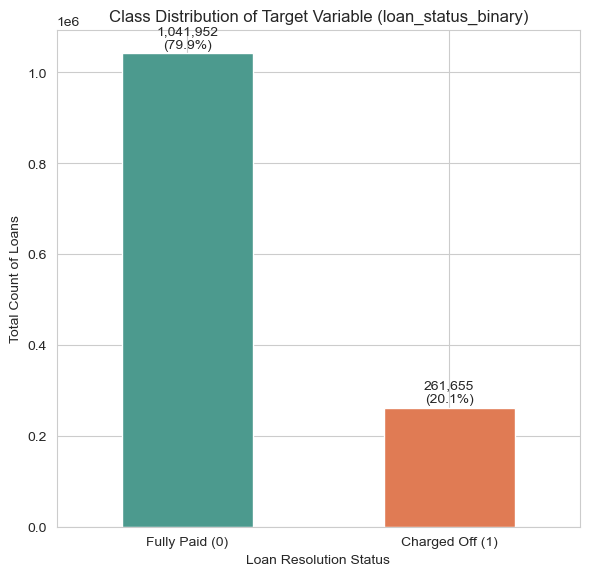

In [8]:
plt.figure(figsize=(6, 6))
ax = status_counts.rename(index={0: "Fully Paid (0)", 1: "Charged Off (1)"}).plot(
    kind="bar", color=["#4C9A8E", "#E07B54"]
)
for i, v in enumerate(status_counts.values):
    ax.text(i, v + 5000, f"{v:,}\n({status_pct.values[i]*100:.1f}%)",
            ha="center", va="bottom", fontsize=10)
plt.title("Class Distribution of Target Variable (loan_status_binary)")
plt.xlabel("Loan Resolution Status")
plt.ylabel("Total Count of Loans")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5b. Missingness chart
Built from the **same train-based series** used for the Section 4 drop decision, so figure and pipeline tell one story.

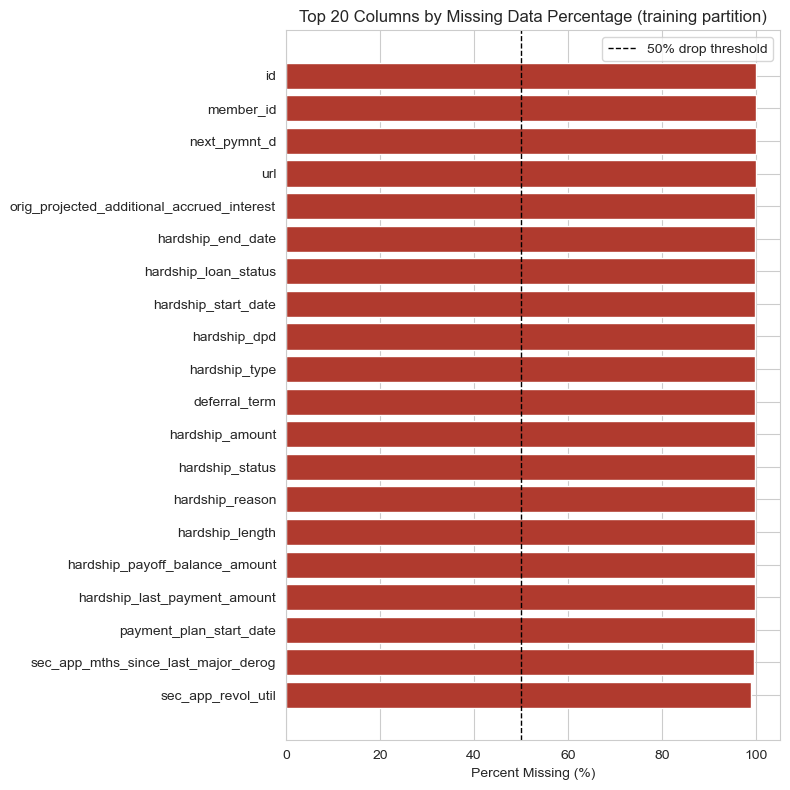

In [9]:
top_missing = missing_frac.head(20)

plt.figure(figsize=(8, 8))
colors = ["#B03A2E" if v > 0.50 else "#5DADE2" for v in top_missing.values]
plt.barh(top_missing.index[::-1], top_missing.values[::-1] * 100, color=colors[::-1])
plt.axvline(50, color="black", linestyle="--", linewidth=1, label="50% drop threshold")
plt.xlabel("Percent Missing (%)")
plt.title("Top 20 Columns by Missing Data Percentage (training partition)")
plt.legend()
plt.tight_layout()
plt.show()

### 5c. Correlation heatmap

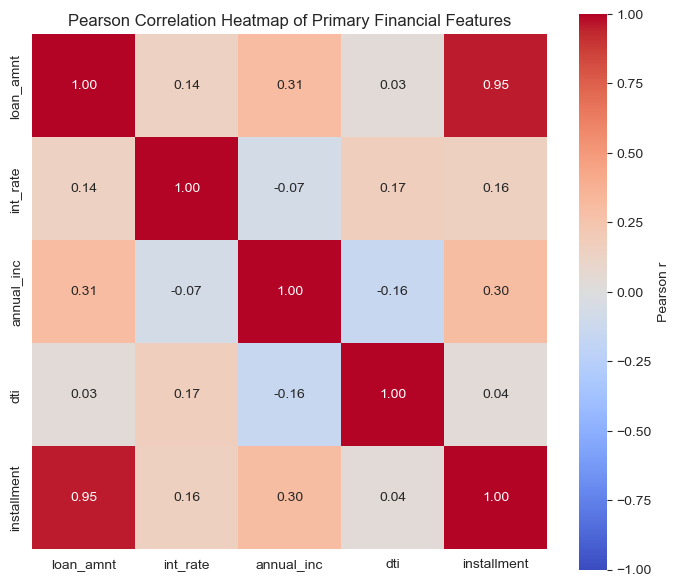

loan_amnt vs installment correlation: 0.953


In [10]:
heatmap_vars = ["loan_amnt", "int_rate", "annual_inc", "dti", "installment"]
corr_matrix = df[heatmap_vars].corr(method="pearson")

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, square=True, cbar_kws={"label": "Pearson r"},
)
plt.title("Pearson Correlation Heatmap of Primary Financial Features")
plt.tight_layout()
plt.show()

print(f"loan_amnt vs installment correlation: "
      f"{corr_matrix.loc['loan_amnt', 'installment']:.3f}")

### 5d. Interest rate box plot + Welch's t-test

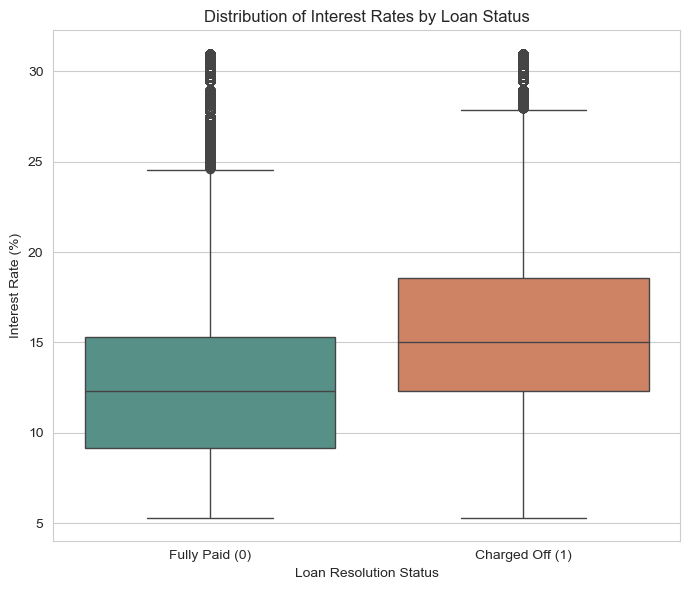

Median int_rate - Fully Paid: 12.29%
Median int_rate - Charged Off: 15.05%
Welch's t-test: t = 291.139, p = 0


In [11]:
plt.figure(figsize=(7, 6))
sns.boxplot(data=df, x="loan_status_binary", y="int_rate",
            hue="loan_status_binary",
            palette={0: "#4C9A8E", 1: "#E07B54"}, legend=False)
plt.xticks([0, 1], ["Fully Paid (0)", "Charged Off (1)"])
plt.xlabel("Loan Resolution Status")
plt.ylabel("Interest Rate (%)")
plt.title("Distribution of Interest Rates by Loan Status")
plt.tight_layout()
plt.show()

paid = df.loc[df["loan_status_binary"] == 0, "int_rate"].dropna()
charged_off = df.loc[df["loan_status_binary"] == 1, "int_rate"].dropna()
t_stat, p_val = stats.ttest_ind(charged_off, paid, equal_var=False)
print(f"Median int_rate - Fully Paid: {paid.median():.2f}%")
print(f"Median int_rate - Charged Off: {charged_off.median():.2f}%")
print(f"Welch's t-test: t = {t_stat:.3f}, p = {p_val:.4g}")

### 5e. DTI box plot + Welch's t-test

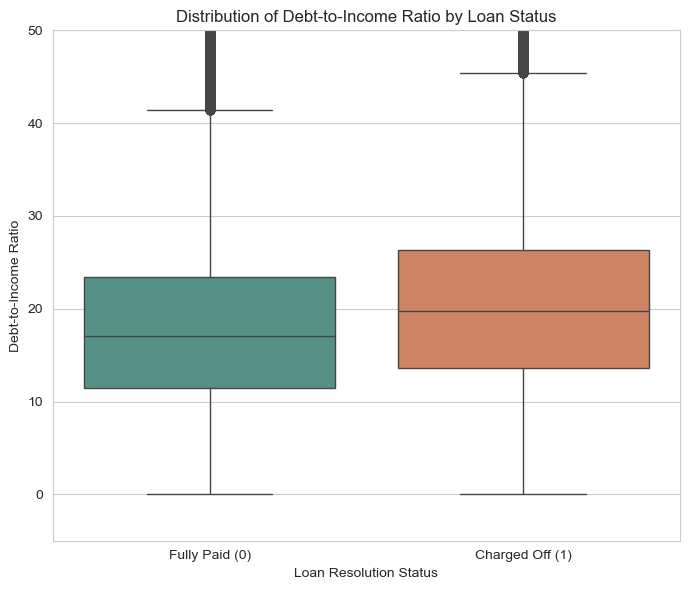

Median DTI - Fully Paid: 17.09
Median DTI - Charged Off: 19.77
Welch's t-test (DTI): t = 108.922, p = 0


In [12]:
plt.figure(figsize=(7, 6))
sns.boxplot(data=df, x="loan_status_binary", y="dti",
            hue="loan_status_binary",
            palette={0: "#4C9A8E", 1: "#E07B54"}, legend=False)
plt.ylim(-5, 50)
plt.xticks([0, 1], ["Fully Paid (0)", "Charged Off (1)"])
plt.xlabel("Loan Resolution Status")
plt.ylabel("Debt-to-Income Ratio")
plt.title("Distribution of Debt-to-Income Ratio by Loan Status")
plt.tight_layout()
plt.show()

dti_paid = df.loc[df["loan_status_binary"] == 0, "dti"].dropna()
dti_charged_off = df.loc[df["loan_status_binary"] == 1, "dti"].dropna()
t_stat_dti, p_val_dti = stats.ttest_ind(dti_charged_off, dti_paid, equal_var=False)
print(f"Median DTI - Fully Paid: {dti_paid.median():.2f}")
print(f"Median DTI - Charged Off: {dti_charged_off.median():.2f}")
print(f"Welch's t-test (DTI): t = {t_stat_dti:.3f}, p = {p_val_dti:.4g}")

### 5f. Grade stacked bar + chi-square

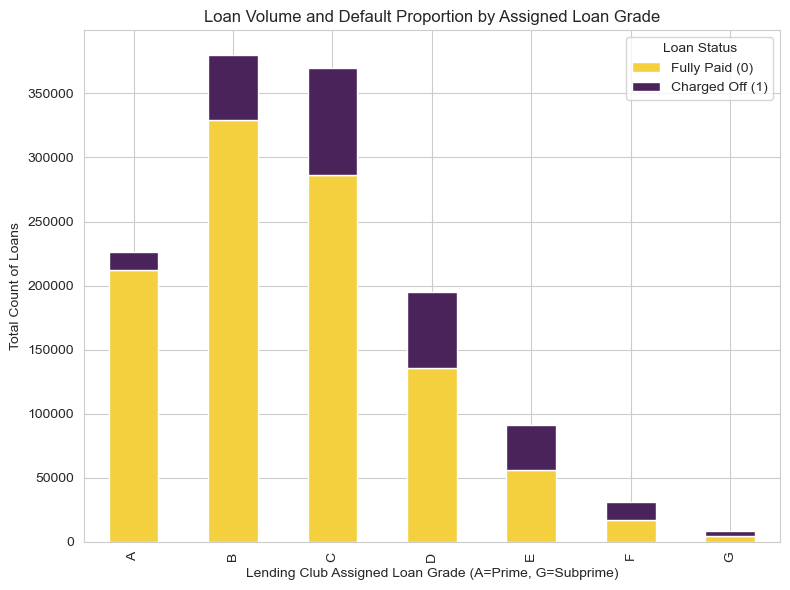

Chi-Square test (grade vs default): chi2 = 89626.70, p = 0, dof = 6

EDA complete.


In [13]:
grade_status = pd.crosstab(df["grade"], df["loan_status_binary"])
grade_status = grade_status.reindex(sorted(grade_status.index))
grade_status.columns = ["Fully Paid (0)", "Charged Off (1)"]

ax = grade_status.plot(kind="bar", stacked=True,
                       color=["#F4D03F", "#4A235A"], figsize=(8, 6))
plt.title("Loan Volume and Default Proportion by Assigned Loan Grade")
plt.xlabel("Lending Club Assigned Loan Grade (A=Prime, G=Subprime)")
plt.ylabel("Total Count of Loans")
plt.legend(title="Loan Status")
plt.tight_layout()
plt.show()

chi2, chi_p, dof, expected = stats.chi2_contingency(grade_status)
print(f"Chi-Square test (grade vs default): chi2 = {chi2:.2f}, "
      f"p = {chi_p:.4g}, dof = {dof}")

print("\nEDA complete.")

## 6. Variable Inventory (post sparsity-threshold)

In [14]:
print(f"Total columns remaining after 50% missing drop: {df_train.shape[1]}")
print("\nColumns remaining:")
for col in df_train.columns:
    print(f" - {col} ({df_train[col].dtype})")

Total columns remaining after 50% missing drop: 88

Columns remaining:
 - loan_amnt (int64)
 - funded_amnt (int64)
 - funded_amnt_inv (float64)
 - term (object)
 - int_rate (float64)
 - installment (float64)
 - grade (object)
 - sub_grade (object)
 - emp_title (object)
 - emp_length (object)
 - home_ownership (object)
 - annual_inc (float64)
 - verification_status (object)
 - issue_d (object)
 - loan_status (object)
 - pymnt_plan (object)
 - purpose (object)
 - title (object)
 - zip_code (object)
 - addr_state (object)
 - dti (float64)
 - delinq_2yrs (float64)
 - earliest_cr_line (object)
 - inq_last_6mths (float64)
 - open_acc (float64)
 - pub_rec (float64)
 - revol_bal (int64)
 - revol_util (float64)
 - total_acc (float64)
 - initial_list_status (object)
 - out_prncp (float64)
 - out_prncp_inv (float64)
 - total_pymnt (float64)
 - total_pymnt_inv (float64)
 - total_rec_prncp (float64)
 - total_rec_int (float64)
 - total_rec_late_fee (float64)
 - recoveries (float64)
 - collection_rec

## 7. VIF Check on Candidate Numeric Features (TRAIN only, threshold = 5)
Numeric candidates are selected programmatically: every numeric-dtype column minus documented exclusions (target, post-origination leakage, near-constant, grade-adjacent).

**Note:** the iterative VIF loop is the slowest part of the pipeline — expect a long runtime.

In [15]:
all_numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()

target_col = ["loan_status_binary"]
leakage_cols = [
    "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee",
    "recoveries", "collection_recovery_fee", "last_pymnt_amnt",
]
id_or_constant_cols = ["policy_code"]
grade_adjacent_cols = ["int_rate", "installment", "funded_amnt", "funded_amnt_inv"]

exclude_cols = target_col + leakage_cols + id_or_constant_cols + grade_adjacent_cols
numeric_candidate_cols = [c for c in all_numeric_cols if c not in exclude_cols]

print(f"Numeric columns in df_train: {len(all_numeric_cols)}")
print(f"Excluded: {len(exclude_cols)}")
print(f"Numeric candidates for VIF: {len(numeric_candidate_cols)}")
print(numeric_candidate_cols)

X_numeric_train = df_train[numeric_candidate_cols].dropna()
print(f"\nTrain rows available for VIF check after dropna: "
      f"{X_numeric_train.shape[0]} of {df_train.shape[0]}")

Numeric columns in df_train: 66
Excluded: 16
Numeric candidates for VIF: 50
['loan_amnt', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit']

Train rows availa

In [16]:
def iterative_vif_selection(X, threshold=5.0, verbose=True):
    """Repeatedly drop the single highest-VIF column and recompute
    until every remaining column is at or below the threshold."""
    X = X.copy()
    dropped = []
    while True:
        vif = pd.Series(
            [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
            index=X.columns
        )
        max_vif = vif.max()
        if max_vif <= threshold:
            break
        drop_col = vif.idxmax()
        if verbose:
            print(f"Dropping {drop_col} (VIF = {max_vif:.2f})")
        dropped.append((drop_col, max_vif))
        X = X.drop(columns=[drop_col])
    return X, vif, dropped


X_vif5, final_vif5, dropped5 = iterative_vif_selection(X_numeric_train, threshold=5.0)
print(f"\n=== VIF Pruning on TRAIN (threshold = 5) ===")
print(f"Features retained: {X_vif5.shape[1]} of {X_numeric_train.shape[1]}")
print(f"Features dropped: {len(dropped5)}")
print(final_vif5.sort_values(ascending=False))

numeric_features = list(X_vif5.columns)

Dropping open_acc (VIF = 4703.97)
Dropping total_acc (VIF = 2056.92)
Dropping num_actv_rev_tl (VIF = 1646.50)
Dropping num_op_rev_tl (VIF = 84.02)
Dropping tot_cur_bal (VIF = 64.10)
Dropping total_bal_ex_mort (VIF = 40.30)
Dropping bc_util (VIF = 38.05)
Dropping num_bc_sats (VIF = 34.02)
Dropping num_rev_accts (VIF = 31.74)
Dropping pct_tl_nvr_dlq (VIF = 31.51)
Dropping num_sats (VIF = 20.48)
Dropping total_bc_limit (VIF = 20.40)
Dropping num_rev_tl_bal_gt_0 (VIF = 15.51)
Dropping revol_util (VIF = 14.19)
Dropping total_rev_hi_lim (VIF = 13.70)
Dropping tot_hi_cred_lim (VIF = 10.98)
Dropping pub_rec (VIF = 10.00)
Dropping acc_open_past_24mths (VIF = 8.64)
Dropping mo_sin_old_il_acct (VIF = 7.77)
Dropping num_bc_tl (VIF = 7.61)
Dropping mo_sin_old_rev_tl_op (VIF = 5.38)
Dropping dti (VIF = 5.16)

=== VIF Pruning on TRAIN (threshold = 5) ===
Features retained: 28 of 50
Features dropped: 22
num_actv_bc_tl                4.695484
loan_amnt                     4.548499
acc_now_delinq       

## 8. Categorical Selection + Rare-Level Collapsing (TRAIN-derived)
Categoricals are selected programmatically (all string columns minus documented exclusions). Rare levels are collapsed into `Other` using **train counts only**; `addr_state` uses a higher threshold (5000) so its `Other` bucket pools several small states rather than effectively containing only Iowa.

In [17]:
all_categorical_cols = df_train.select_dtypes(include=["object", "string"]).columns.tolist()

cat_target_adjacent = ["loan_status"]
cat_leakage = ["hardship_flag", "debt_settlement_flag",
               "last_pymnt_d", "last_credit_pull_d"]
cat_already_dropped = ["sub_grade", "pymnt_plan"]
cat_freetext_or_id = ["emp_title", "title", "zip_code"]
cat_raw_dates = ["issue_d", "earliest_cr_line"]
cat_grade = ["grade"]  # handled separately (Model B / tree models)

cat_exclude = (cat_target_adjacent + cat_leakage + cat_already_dropped
               + cat_freetext_or_id + cat_raw_dates + cat_grade)

categorical_features = [c for c in all_categorical_cols if c not in cat_exclude]

print(f"Categorical columns in df_train: {len(all_categorical_cols)}")
print(f"Excluded: {len(cat_exclude)}")
print(f"Categorical features for modeling: {categorical_features}")

Categorical columns in df_train: 22
Excluded: 13
Categorical features for modeling: ['term', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type', 'disbursement_method']


In [18]:
MIN_LEVEL_COUNT_DEFAULT = 1000
MIN_LEVEL_COUNT_BY_COL = {"addr_state": 5000}

df_train = df_train.copy()
df_test = df_test.copy()

for col in categorical_features + ["grade"]:
    min_count = MIN_LEVEL_COUNT_BY_COL.get(col, MIN_LEVEL_COUNT_DEFAULT)
    train_counts = df_train[col].value_counts()
    rare_levels = train_counts[train_counts < min_count].index
    if len(rare_levels) > 0:
        print(f"{col}: collapsing {len(rare_levels)} rare level(s) "
              f"(<{min_count} train rows) into 'Other': {list(rare_levels)}")
        df_train[col] = df_train[col].where(~df_train[col].isin(rare_levels), "Other")
        df_test[col] = df_test[col].where(~df_test[col].isin(rare_levels), "Other")
    unseen = set(df_test[col].dropna().unique()) - set(df_train[col].dropna().unique())
    if unseen:
        print(f"{col}: mapping unseen test level(s) {unseen} to 'Other'")
        df_test[col] = df_test[col].where(~df_test[col].isin(unseen), "Other")

# Safety check: report class balance inside each collapsed "Other" bucket
# so separation can't hide there silently.
print()
for col in categorical_features + ["grade"]:
    if (df_train[col] == "Other").any():
        other_rows = df_train[df_train[col] == "Other"]
        n = len(other_rows)
        d = int(other_rows["loan_status_binary"].sum())
        print(f"{col}='Other': {n} train rows, {d} defaults "
              f"({(d / n * 100) if n else 0:.1f}%)")

target = "loan_status_binary"

home_ownership: collapsing 3 rare level(s) (<1000 train rows) into 'Other': ['ANY', 'OTHER', 'NONE']
purpose: collapsing 2 rare level(s) (<1000 train rows) into 'Other': ['renewable_energy', 'educational']
addr_state: collapsing 14 rare level(s) (<5000 train rows) into 'Other': ['RI', 'WV', 'MT', 'DE', 'NE', 'DC', 'AK', 'WY', 'SD', 'VT', 'ME', 'ID', 'ND', 'IA']

home_ownership='Other': 374 train rows, 72 defaults (19.3%)
purpose='Other': 961 train rows, 211 defaults (22.0%)
addr_state='Other': 32666 train rows, 5882 defaults (18.0%)


## 9. Model 1: Baseline Logistic Regression — With vs. Without `grade`
Model A excludes `grade`; Model B includes it. Everything else is identical, so any performance difference is attributable to `grade` alone.

In [19]:
model_a_cols = numeric_features + categorical_features
model_b_cols = numeric_features + categorical_features + ["grade"]

train_a = df_train[model_a_cols + [target]].dropna()
train_b = df_train[model_b_cols + [target]].dropna()
test_a = df_test[model_a_cols + [target]].dropna()
test_b = df_test[model_b_cols + [target]].dropna()

print(f"Model A train rows: {train_a.shape[0]} of {df_train.shape[0]} "
      f"({train_a.shape[0] / df_train.shape[0] * 100:.1f}%)")
print(f"Model B train rows: {train_b.shape[0]} of {df_train.shape[0]} "
      f"({train_b.shape[0] / df_train.shape[0] * 100:.1f}%)")
print(f"Model A test rows: {test_a.shape[0]} of {df_test.shape[0]} "
      f"({test_a.shape[0] / df_test.shape[0] * 100:.1f}%)")
print(f"Model B test rows: {test_b.shape[0]} of {df_test.shape[0]} "
      f"({test_b.shape[0] / df_test.shape[0] * 100:.1f}%)")


def build_formula(numeric_cols, categorical_cols, target):
    """statsmodels R-style formula; C(...) auto-dummy-encodes categoricals."""
    numeric_part = " + ".join(numeric_cols)
    categorical_part = " + ".join([f"C({c})" for c in categorical_cols])
    return f"{target} ~ {numeric_part} + {categorical_part}"

Model A train rows: 797346 of 1042885 (76.5%)
Model B train rows: 797346 of 1042885 (76.5%)
Model A test rows: 199633 of 260722 (76.6%)
Model B test rows: 199633 of 260722 (76.6%)


### 9a. Model 1A: logistic regression without grade

In [20]:
constant_numeric_cols_in_train_a = []
for col in numeric_features:
    # Check for truly constant columns or columns causing numerical instability
    if train_a[col].nunique() <= 1 or train_a[col].std() < 1e-6:
        constant_numeric_cols_in_train_a.append(col)

# Identify and exclude problematic columns that lead to convergence issues
# These columns often have very few non-zero entries, causing quasi-complete separation
problematic_numeric_features = [
    'chargeoff_within_12_mths', 'delinq_amnt', 'num_tl_90g_dpd_24m'
]

filtered_numeric_features = [
    col for col in numeric_features
    if col not in constant_numeric_cols_in_train_a and col not in problematic_numeric_features
]

formula_a = build_formula(filtered_numeric_features, categorical_features, target)
model_a = smf.logit(formula_a, data=train_a).fit(maxiter=200)
print(model_a.summary())

Optimization terminated successfully.
         Current function value: 0.462853
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:     loan_status_binary   No. Observations:               797346
Model:                          Logit   Df Residuals:                   797252
Method:                           MLE   Df Model:                           93
Date:                Sun, 09 Aug 2026   Pseudo R-squ.:                 0.07951
Time:                        22:46:56   Log-Likelihood:            -3.6905e+05
converged:                       True   LL-Null:                   -4.0093e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -

### 9b. Model 1B: logistic regression with grade

In [21]:
formula_b = build_formula(numeric_features, categorical_features + ["grade"], target)
model_b = smf.logit(formula_b, data=train_b).fit(maxiter=200)
print(model_b.summary())

Optimization terminated successfully.
         Current function value: 0.455034
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:     loan_status_binary   No. Observations:               797346
Model:                          Logit   Df Residuals:                   797243
Method:                           MLE   Df Model:                          102
Date:                Sun, 09 Aug 2026   Pseudo R-squ.:                 0.09506
Time:                        22:47:41   Log-Likelihood:            -3.6282e+05
converged:                       True   LL-Null:                   -4.0093e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -

## 10. Extended Metrics
AUC is threshold-independent; accuracy, precision, recall, F1, and FNR require a classification threshold. With the 80/20 imbalance, 0.5 is a poor default — the threshold is selected on **training predictions only** (maximizing F1) and applied to test. Metrics are reported at both 0.5 (reference) and the train-selected threshold.

In [22]:
def pick_threshold_max_f1(y_true, y_prob):
    """Grid-search the F1-maximizing threshold using training data only."""
    best_t, best_f1 = 0.5, -1.0
    for t in np.arange(0.05, 0.95, 0.01):
        f1 = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_t, best_f1 = t, f1
    return best_t


def classification_report_block(name, y_true, y_prob, threshold):
    """Compute and print the full KPI set at a given threshold."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    print(f"\n--- {name} (threshold = {threshold:.2f}) ---")
    print(f"AUC-ROC:   {roc_auc_score(y_true, y_prob):.4f}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"FNR:       {fnr:.4f}  (false negatives = missed defaulters)")
    print(f"Confusion matrix [[TN FP] [FN TP]]: [[{tn} {fp}] [{fn} {tp}]]")

### 10a. Model 1A metrics

In [23]:
train_a_prob = model_a.predict(train_a)
test_a_prob = model_a.predict(test_a)
t_a = pick_threshold_max_f1(train_a[target], train_a_prob)
print("================ MODEL 1A: LOGISTIC (no grade) ================")
print(f"Train AUC: {roc_auc_score(train_a[target], train_a_prob):.4f}")
classification_report_block("TEST @ 0.5", test_a[target], test_a_prob, 0.5)
classification_report_block("TEST @ train-optimal", test_a[target], test_a_prob, t_a)

================ MODEL 1A: LOGISTIC (no grade) ================
Train AUC: 0.6969

--- TEST @ 0.5 (threshold = 0.50) ---
AUC-ROC:   0.6937
Accuracy:  0.8004
Precision: 0.5544
Recall:    0.0578
F1-score:  0.1047
FNR:       0.9422  (false negatives = missed defaulters)
Confusion matrix [[TN FP] [FN TP]]: [[157463 1873] [37967 2330]]

--- TEST @ train-optimal (threshold = 0.21) ---
AUC-ROC:   0.6937
Accuracy:  0.6594
Precision: 0.3191
Recall:    0.6063
F1-score:  0.4181
FNR:       0.3937  (false negatives = missed defaulters)
Confusion matrix [[TN FP] [FN TP]]: [[107199 52137] [15864 24433]]


### 10b. Model 1B metrics

In [24]:
train_b_prob = model_b.predict(train_b)
test_b_prob = model_b.predict(test_b)
t_b = pick_threshold_max_f1(train_b[target], train_b_prob)
print("================ MODEL 1B: LOGISTIC (with grade) ================")
print(f"Train AUC: {roc_auc_score(train_b[target], train_b_prob):.4f}")
classification_report_block("TEST @ 0.5", test_b[target], test_b_prob, 0.5)
classification_report_block("TEST @ train-optimal", test_b[target], test_b_prob, t_b)

================ MODEL 1B: LOGISTIC (with grade) ================
Train AUC: 0.7142

--- TEST @ 0.5 (threshold = 0.50) ---
AUC-ROC:   0.7120
Accuracy:  0.8008
Precision: 0.5523
Recall:    0.0697
F1-score:  0.1237
FNR:       0.9303  (false negatives = missed defaulters)
Confusion matrix [[TN FP] [FN TP]]: [[157061 2275] [37490 2807]]

--- TEST @ train-optimal (threshold = 0.22) ---
AUC-ROC:   0.7120
Accuracy:  0.6699
Precision: 0.3308
Recall:    0.6211
F1-score:  0.4317
FNR:       0.3789  (false negatives = missed defaulters)
Confusion matrix [[TN FP] [FN TP]]: [[108701 50635] [15267 25030]]


## 11. Shared Preparation for Tree Models
Tree models use the **same rows and feature set as Model 1B** (numeric survivors + categoricals + grade) so the three-model comparison is apples-to-apples. Categoricals are one-hot encoded with `pd.get_dummies` fit on TRAIN; the test matrix is reindexed to the train columns.

In [25]:
tree_cats = categorical_features + ["grade"]

# --- Matrix A: one-hot, complete-case — for Random Forest ---
X_train_ohe = pd.get_dummies(train_b[model_b_cols], columns=tree_cats, drop_first=True)
X_test_ohe  = pd.get_dummies(test_b[model_b_cols], columns=tree_cats, drop_first=True)
X_test_ohe  = X_test_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)
y_train_ohe = train_b[target]
y_test_ohe  = test_b[target]

# --- Matrix B: native categorical + NaNs kept — for Gradient Boosting ---
X_train_native = df_train[model_b_cols].copy()
X_test_native  = df_test[model_b_cols].copy()
for c in tree_cats:
    X_train_native[c] = X_train_native[c].astype("category")
    X_test_native[c]  = pd.Categorical(X_test_native[c], categories=X_train_native[c].cat.categories)
y_train_native = df_train[target]
y_test_native  = df_test[target]

print(f"OHE matrix (RF):    {X_train_ohe.shape[1]} cols, {X_train_ohe.shape[0]} train rows")
print(f"Native matrix (GB): {X_train_native.shape[1]} cols, {X_train_native.shape[0]} train rows")

OHE matrix (RF):    102 cols, 797346 train rows
Native matrix (GB): 38 cols, 1042885 train rows


## 12. Model 2: Random Forest
`class_weight='balanced'` reweights the loss for the 80/20 imbalance; `min_samples_leaf` and `n_jobs` keep runtime manageable. Expect several minutes.

In [26]:
rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=300,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train_ohe, y_train_ohe)

rf_train_prob = rf.predict_proba(X_train_ohe)[:, 1]
rf_test_prob  = rf.predict_proba(X_test_ohe)[:, 1]

t_rf = pick_threshold_max_f1(y_train_ohe, rf_train_prob)

print("================ MODEL 2: RANDOM FOREST ================")
print(f"Train AUC: {roc_auc_score(y_train_ohe, rf_train_prob):.4f}")
classification_report_block("TEST @ 0.5", y_test_ohe, rf_test_prob, 0.5)
classification_report_block("TEST @ train-optimal", y_test_ohe, rf_test_prob, t_rf)

================ MODEL 2: RANDOM FOREST ================
Train AUC: 0.7228

--- TEST @ 0.5 (threshold = 0.50) ---
AUC-ROC:   0.7091
Accuracy:  0.6526
Precision: 0.3213
Recall:    0.6482
F1-score:  0.4296
FNR:       0.3518  (false negatives = missed defaulters)
Confusion matrix [[TN FP] [FN TP]]: [[104151 55185] [14176 26121]]

--- TEST @ train-optimal (threshold = 0.51) ---
AUC-ROC:   0.7091
Accuracy:  0.6665
Precision: 0.3284
Recall:    0.6240
F1-score:  0.4303
FNR:       0.3760  (false negatives = missed defaulters)
Confusion matrix [[TN FP] [FN TP]]: [[107914 51422] [15153 25144]]


### 12a. Random Forest feature importances

In [27]:
rf_importance = pd.Series(rf.feature_importances_, index=X_train_ohe.columns)
print("Top 15 Random Forest feature importances:")
print(rf_importance.sort_values(ascending=False).head(15).round(4).to_string())

Top 15 Random Forest feature importances:
term_ 60 months          0.2142
grade_E                  0.0840
grade_D                  0.0794
grade_B                  0.0755
bc_open_to_buy           0.0627
avg_cur_bal              0.0537
grade_C                  0.0512
loan_amnt                0.0447
mort_acc                 0.0374
grade_F                  0.0353
annual_inc               0.0295
num_tl_op_past_12m       0.0291
percent_bc_gt_75         0.0281
home_ownership_RENT      0.0251
mths_since_recent_inq    0.0155


## 13. Model 3: Gradient Boosting
`HistGradientBoostingClassifier` is sklearn's fast histogram-based GBDT (same family as LightGBM/XGBoost).

In [28]:
gb = HistGradientBoostingClassifier(
    max_iter=1000,
    learning_rate=0.03,
    class_weight="balanced",
    categorical_features="from_dtype",
    random_state=42,
)
gb.fit(X_train_native, y_train_native)

gb_train_prob = gb.predict_proba(X_train_native)[:, 1]
gb_test_prob  = gb.predict_proba(X_test_native)[:, 1]
t_gb = pick_threshold_max_f1(y_train_native, gb_train_prob)

print("================ MODEL 3: GRADIENT BOOSTING ================")
print(f"Train AUC: {roc_auc_score(y_train_native, gb_train_prob):.4f}")
classification_report_block("TEST @ 0.5", y_test_native, gb_test_prob, 0.5)
classification_report_block("TEST @ train-optimal", y_test_native, gb_test_prob, t_gb)

================ MODEL 3: GRADIENT BOOSTING ================
Train AUC: 0.7396

--- TEST @ 0.5 (threshold = 0.50) ---
AUC-ROC:   0.7247
Accuracy:  0.6551
Precision: 0.3265
Recall:    0.6760
F1-score:  0.4403
FNR:       0.3240  (false negatives = missed defaulters)
Confusion matrix [[TN FP] [FN TP]]: [[135415 72976] [16955 35376]]

--- TEST @ train-optimal (threshold = 0.53) ---
AUC-ROC:   0.7247
Accuracy:  0.6847
Precision: 0.3428
Recall:    0.6223
F1-score:  0.4421
FNR:       0.3777  (false negatives = missed defaulters)
Confusion matrix [[TN FP] [FN TP]]: [[145948 62443] [19765 32566]]


## 14. Model Comparison Summary
Final TEST AUC comparison across all models.

In [29]:
print("================ MODEL COMPARISON (TEST AUC) ================")
print(f"Model 1A - Logistic, no grade:   {roc_auc_score(test_a[target], test_a_prob):.4f}")
print(f"Model 1B - Logistic, with grade: {roc_auc_score(test_b[target], test_b_prob):.4f}")
print(f"Model 2  - Random Forest:        {roc_auc_score(y_test_ohe, rf_test_prob):.4f}")
print(f"Model 3  - Gradient Boosting:    {roc_auc_score(y_test_native, gb_test_prob):.4f}")

================ MODEL COMPARISON (TEST AUC) ================
Model 1A - Logistic, no grade:   0.6937
Model 1B - Logistic, with grade: 0.7120
Model 2  - Random Forest:        0.7091
Model 3  - Gradient Boosting:    0.7247
